# 1. Importación

Carga de las librerías, del modelo final guardado por `04_model_training.ipynb` (`models/malaga/price_model.pkl`, `models/malaga/model_metadata.json`) y del test (`data/processed/malaga/listings_test.csv`). Este notebook no reentrena nada, parte de lo que ya quedó guardado.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
final_pipeline = joblib.load("/Users/yagocoll/Documents/Master/Airbnb/models/malaga/price_model.pkl")

with open("/Users/yagocoll/Documents/Master/Airbnb/models/malaga/model_metadata.json") as f:
    metadata = json.load(f)

test_df = pd.read_csv("/Users/yagocoll/Documents/Master/Airbnb/data/processed/malaga/listings_test.csv")
metadata["test_metrics"]

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': 154.670915347163,
 'MAE': 52.19319678073402,
 'R2': 0.5655606506519071,
 'MAPE': 22.293957420282098,
 'R2_log': 0.7824154245690116}

## 2. Reconstruir predicciones

Mismos `feature_cols`/`target` que en el entrenamiento (guardados en `metadata`), para tener `y_test` y las predicciones disponibles para todo el análisis que sigue.

### 2.1 X e y de test

In [3]:
feature_cols = metadata["feature_cols"]
target_col = metadata["target"]

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

bool_cols = X_test.select_dtypes(include="bool").columns
X_test[bool_cols] = X_test[bool_cols].astype(int)

X_test.shape

(1749, 74)

### 2.2 Función `evaluate`

In [4]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 2.3 Predecir

El modelo predice en escala `log1p(price)`; se deshace con `expm1` antes de evaluar nada.

In [5]:
pred = np.expm1(final_pipeline.predict(X_test))
residuals = pred - y_test.values

evaluate(y_test, pred, "Hist Gradient Boosting")

{'modelo': 'Hist Gradient Boosting',
 'RMSE': np.float64(154.670915347163),
 'MAE': 52.19319678073402,
 'R2': 0.5655606506519071,
 'MAPE': np.float64(22.293957420282098)}

Coincide exactamente con `metadata["test_metrics"]` (RMSE=154.67€, MAE=52.19€, R²=0.57, MAPE=22.29%): el modelo cargado predice igual que cuando se guardó, así que el análisis de errores parte de una base fiable.

Como se vio en `04_model_training.ipynb`, `has_pool` entró en el top 15 de importancia por permutación, y `latitude`/`longitude` pesaron más que la codificación de barrio/distrito — un matiz propio de Málaga que conviene tener presente al leer los errores por zona en la sección 4.

## 3. Predicción vs. realidad

Scatter de precio predicho contra precio real, y distribución de los residuos (`predicho - real`). El objetivo es detectar sesgos sistemáticos que un único R² no muestra.

### 3.1 Predicho vs. real

(0.0, 1500.0)

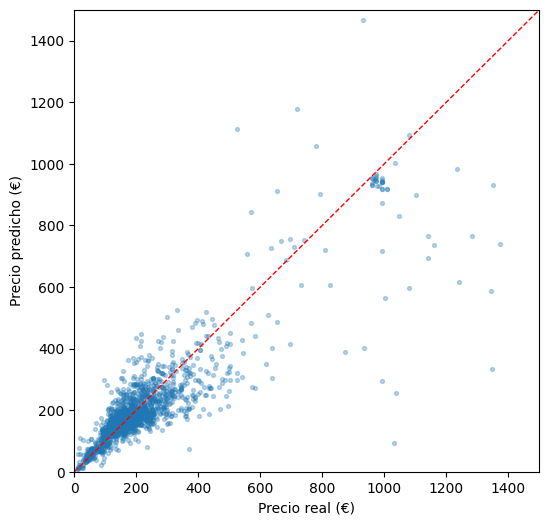

In [6]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, s=8, alpha=0.3)
lims = [0, 1500]
plt.plot(lims, lims, "r--", linewidth=1)
plt.xlabel("Precio real (€)")
plt.ylabel("Precio predicho (€)")
plt.xlim(lims)
plt.ylim(lims)

Para precios bajos y medios los puntos siguen razonablemente la diagonal. A partir de unos 300-400€, cada vez más puntos caen por debajo: **el modelo tiende a subestimar los anuncios más caros**, el mismo patrón que en las otras tres ciudades. El gráfico se recorta en 1500€ por claridad visual; unas pocas villas del test llegan hasta 4573€ y quedan fuera de esta ventana (se tratan en la sección 5).

### 3.2 Distribución de los residuos

Media: -14.253488504064697
Mediana: 1.0071264877737462


(-500.0, 500.0)

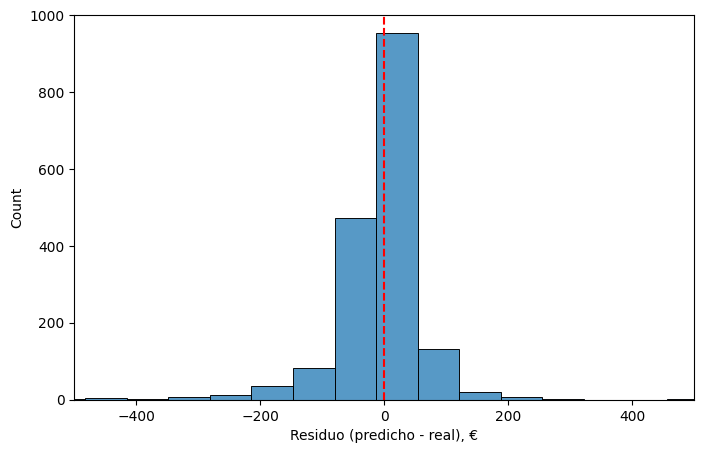

In [7]:
print("Media:", residuals.mean())
print("Mediana:", np.median(residuals))

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60)
plt.axvline(0, color="r", linestyle="--")
plt.xlabel("Residuo (predicho - real), €")
plt.xlim(-500, 500)

La mediana del residuo es prácticamente 0 (+1.01€), pero la **media es -14.25€**, bastante más negativa — la misma lección que en las otras ciudades: hay una cola de subestimaciones grandes en una sola dirección que arrastra la media, aunque la mitad de los anuncios se acierten casi exactos.

### 3.3 ¿El sesgo depende del precio?

(0.0, 1500.0)

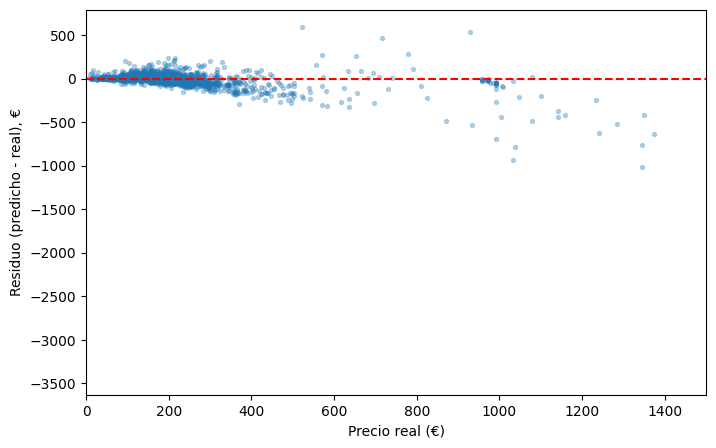

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals, s=8, alpha=0.3)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Precio real (€)")
plt.ylabel("Residuo (predicho - real), €")
plt.xlim(0, 1500)

In [9]:
price_quintile = pd.qcut(y_test, 5)
pd.DataFrame({"residual": residuals}).groupby(price_quintile, observed=True)["residual"].agg(["mean", "median", "count"])

,mean,median,count
price,,,
"(8.229000000000001, 121.868]",18.166158,14.431795,350
"(121.868, 154.0]",17.779923,13.680956,351
"(154.0, 191.0]",7.786689,1.165078,353
"(191.0, 257.7]",-9.191481,-18.806124,345
"(257.7, 4573.5]",-106.016858,-63.707449,350


Confirmado con números: en los dos quintiles más bajos el residuo medio es **positivo** (+18.2€, +17.8€, el modelo sobreestima los anuncios más baratos), el tercero está casi en cero (+7.8€), el cuarto ya es negativo (-9.2€), y en el quintil más caro (por encima de 258€) el residuo medio es **-106.0€** (mediana -63.7€) — la subestimación más severa de las cuatro ciudades en euros absolutos, coherente con ser también la ciudad con la cola de precio más extrema tras la limpieza de la EDA (villas de hasta 4573€ en el propio test).

Misma explicación que en las otras ciudades: al optimizar sobre `log1p(price)`, un error relativo pequeño en la cola alta se traduce en un error absoluto grande al deshacer el logaritmo. El sesgo hacia sobreestimar lo barato y subestimar lo caro es una limitación real del modelo, no una anécdota.

## 4. Errores por segmento

MAE/RMSE desglosados por `room_type`, por distrito y por rango de precio.

### 4.1 Por `room_type`

In [10]:
room_type_cols = [c for c in feature_cols if c.startswith("room_type_")]
room_type_series = X_test[room_type_cols].idxmax(axis=1).str.replace("room_type_", "", regex=False)

rows = []
for rt in room_type_series.unique():
    mask = (room_type_series == rt).values
    scores = evaluate(y_test[mask], pred[mask], rt)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Entire home/apt,162.85,55.88,0.54,21.68,1564
Private room,35.46,19.48,0.58,27.91,177
Shared room,10.53,9.02,0.72,15.02,7
Hotel room,375.37,375.37,NaN,32.87,1


`Entire home/apt` (1564 filas, la gran mayoría del test) tiene el RMSE/MAE más altos en euros (162.85€/55.88€), esperable por ser la categoría con precios más altos y dispersos (incluidas todas las villas). `Private room` tiene errores mucho más bajos (MAE=19.48€) y un R² incluso mejor (0.58 vs. 0.54). `Shared room` (7 filas, R²=0.72) va bien pese a la muestra pequeña; `Hotel room` (1 fila) no permite calcular R² — con una sola fila ni siquiera hay varianza que explicar.

### 4.2 Por distrito

In [11]:
district_cols = [c for c in feature_cols if c.startswith("district_")]
district_series = X_test[district_cols].idxmax(axis=1).str.replace("district_", "", regex=False)

rows = []
for d in district_series.unique():
    mask = (district_series == d).values
    scores = evaluate(y_test[mask], pred[mask], d)
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2).sort_values("n", ascending=False)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
Centro,77.92,43.88,0.78,21.03,1161
Carretera de Cadiz,56.97,37.50,0.69,24.21,176
Este,433.25,128.18,0.39,26.77,167
Cruz de Humilladero,42.84,26.80,0.77,18.49,81
Bailen-Miraflores,50.39,29.70,0.65,20.09,62
Palma-Palmilla,92.72,52.21,0.79,30.19,33
Churriana,208.78,115.03,0.34,32.56,25
Ciudad Jardin,178.74,88.89,0.73,32.29,16
Teatinos-Universidad,75.01,46.36,0.59,28.18,13


**`Este` destaca muy negativamente**: RMSE=433.25€ y R²=0.39, con diferencia el peor resultado en euros de todos los distritos, pese a una muestra nada pequeña (167 filas). `Campanillas` (R²=0.29, 9 filas) y `Churriana` (R²=0.34, 25 filas) también salen mal, pero con muestras minúsculas donde un par de errores grandes bastan para hundir el R². El resto de distritos se mueve en un rango mucho más razonable (R² 0.59-0.79, con `Palma-Palmilla` a la cabeza), y `Centro` — el 66% del test — tiene un R²=0.78 sólido pese a concentrar la inmensa mayoría de anuncios.

El caso de `Este` se explica casi por completo en la sección 5: **5 de los 15 peores errores de todo el test** son anuncios grandes sin ninguna reseña, y los cinco están en `Este`. No es un problema general de la zona, es un puñado de anuncios concretos y sospechosos concentrados geográficamente ahí.

### 4.3 Por rango de precio

In [12]:
price_quintile = pd.qcut(y_test, 5)

rows = []
for q in price_quintile.cat.categories:
    mask = (price_quintile == q).values
    scores = evaluate(y_test[mask].values, pred[mask], str(q))
    scores["n"] = mask.sum()
    rows.append(scores)

pd.DataFrame(rows).set_index("modelo").round(2)

,RMSE,MAE,R2,MAPE,n
modelo,,,,,
"(8.229000000000001, 121.868]",35.48,25.17,-0.32,33.62,350
"(121.868, 154.0]",33.29,23.30,-11.40,16.91,351
"(154.0, 191.0]",39.07,28.01,-11.11,16.41,353
"(191.0, 257.7]",57.08,44.03,-7.71,19.97,345
"(257.7, 4573.5]",335.30,140.62,0.34,24.59,350


El MAE crece con fuerza en el quintil más caro (25.2€ → 23.3€ → 28.0€ → 44.0€ → 140.6€), coherente con la sección 3. El R² por quintil sale negativo en casi todos los tramos, por el mismo motivo que en las otras ciudades: al cortar por rangos de precio, la variabilidad *dentro* de cada quintil es pequeña por construcción, y ahí el R² deja de ser una métrica útil. Para segmentar por precio conviene mirar MAE/RMSE en euros, no R².

## 5. Los peores casos

Los anuncios con mayor error absoluto, inspeccionados uno a uno.

### 5.1 Los 15 mayores errores absolutos

In [13]:
worst_idx = np.argsort(-np.abs(residuals))[:15]

cols_show = ["id", "price", "bedrooms", "accommodates", "minimum_nights", "bathrooms"]
worst = test_df.iloc[worst_idx][cols_show].copy()
worst["room_type"] = room_type_series.iloc[worst_idx].values
worst["pred"] = pred[worst_idx]
worst["residual"] = residuals[worst_idx]
worst

,id,price,bedrooms,accommodates,minimum_nights,bathrooms,room_type,pred,residual
258,1652063448467021310,4452.00,5.0,10,1.0,3.0,Entire home/apt,1022.358055,-3429.641945
621,854198620057958506,4573.50,5.0,12,1.0,5.5,Entire home/apt,1175.763145,-3397.736855
959,1632535178341081918,2360.00,1.0,3,1.0,1.0,Entire home/apt,176.743669,-2183.256331
1248,1693290712210201267,1346.00,2.0,4,1.0,1.0,Entire home/apt,332.551116,-1013.448884
709,9231129,1031.95,1.0,2,7.0,1.0,Entire home/apt,92.945393,-939.004607
1503,672129241188114600,1036.67,3.0,6,6.0,1.5,Entire home/apt,255.324993,-781.345007
1008,1133435795703494975,1344.50,3.0,8,2.0,3.5,Entire home/apt,586.635723,-757.864277
636,751317228208421675,992.00,3.0,6,1.0,1.5,Entire home/apt,293.425369,-698.574631
1351,46726347,1373.00,6.0,16,2.0,4.0,Entire home/apt,738.381229,-634.618771
1152,50429980,1240.00,3.0,5,1.0,1.0,Entire home/apt,615.139880,-624.860120


### 5.2 Cuatro patrones distintos, no uno solo

A diferencia de las otras tres ciudades (donde los 15 peores errores eran siempre subestimaciones), aquí **13 son subestimaciones y 2 son sobreestimaciones** — un patrón nuevo, propio de Málaga.

In [14]:
cols_extra = [
    "id", "price", "bedrooms", "accommodates", "bathrooms", "minimum_nights",
    "has_license", "host_is_superhost", "review_scores_rating", "number_of_reviews",
]
extra = test_df.iloc[worst_idx][cols_extra].copy()
extra["district"] = district_series.iloc[worst_idx].values
extra

,id,price,bedrooms,accommodates,bathrooms,minimum_nights,has_license,host_is_superhost,review_scores_rating,number_of_reviews,district
258,1652063448467021310,4452.00,5.0,10,3.0,1.0,True,False,NaN,0,Este
621,854198620057958506,4573.50,5.0,12,5.5,1.0,True,False,NaN,0,Este
959,1632535178341081918,2360.00,1.0,3,1.0,1.0,True,False,NaN,0,Este
1248,1693290712210201267,1346.00,2.0,4,1.0,1.0,True,False,NaN,0,Centro
709,9231129,1031.95,1.0,2,1.0,7.0,True,False,4.59,37,Centro
1503,672129241188114600,1036.67,3.0,6,1.5,6.0,True,False,5.00,5,Churriana
1008,1133435795703494975,1344.50,3.0,8,3.5,2.0,True,True,5.00,9,Este
636,751317228208421675,992.00,3.0,6,1.5,1.0,True,False,NaN,0,Este
1351,46726347,1373.00,6.0,16,4.0,2.0,True,False,4.87,55,Ciudad Jardin
1152,50429980,1240.00,3.0,5,1.0,1.0,True,False,4.82,11,Este


**Grupo 1 — Group Flats genuinos** (6 de 15, subestimados): `bedrooms` 3-6, `accommodates` 5-16, precios de 934-1373€, con reviews reales (1 a 55, notas de 4.0 a 5.0). El mismo patrón que en las otras ciudades: pisos/villas reales para grupos grandes que el modelo subestima de forma sistemática por la cola alta de `price`.

**Grupo 2 — anuncios grandes sin ninguna reseña, concentrados en un distrito** (6 de 15, subestimados): `bedrooms` 1-5, `accommodates` 3-12, **0 reviews** en los seis, precios de 992-4573€. La coincidencia más llamativa de este notebook: **5 de los 6 están en `Este`** (el sexto, de 1346€, está en `Centro`) — exactamente el distrito que peor R² sacaba en la sección 4.2. Sin ninguna reserva real detrás, estos precios no tienen por qué reflejar mercado (el mismo patrón "anuncio sin actividad" ya visto en Barcelona/Valencia), pero aquí además explican por sí solos la mayor parte del mal resultado agregado de todo un distrito.

**Grupo 3 — pequeño pero popular, precio disparado** (1 de 15, subestimado): el id `9231129` es un apartamento de 1 dormitorio para 2 personas, con **37 reviews reales y nota 4.59**, a 1031.95€/noche con `minimum_nights=7`. El mismo fenómeno "anti-booking al revés" de Valencia (anuncio genuinamente popular con un precio puntual muy por encima de lo que su tamaño sugiere), aquí como caso aislado en vez de grupo numeroso.

**Grupo 4 — el hallazgo nuevo: casas grandes sobreestimadas por ser demasiado baratas** (2 de 15, sobreestimados, no visto en las otras ciudades): `bedrooms` 7-8, `accommodates` 13-14, pero precios de solo 523-930€ — baratísimos para ese tamaño (compárese con el Grupo 1, donde tamaños similares rondan los 1000-1400€). El modelo, que ha aprendido que "más grande = más caro", sobreestima con fuerza (+536€ y +589€) precisamente porque estas dos casas no siguen ese patrón. Un caso (523€) no tiene ninguna reseña, tan dudoso como el Grupo 2 pero por precio demasiado bajo en vez de demasiado alto; el otro (930€) tiene **14 reviews reales con nota perfecta (5.0)** — una villa grande genuinamente barata, no un error de datos.

En conjunto, los peores errores tienen cuatro causas distintas. Ninguna se soluciona con más ajuste de hiperparámetros: la primera necesitaría tratar la cola alta de otra forma; la segunda y la tercera necesitarían una detección más general de precios no realistas antes de entrenar; la cuarta apunta a lo contrario, anuncios grandes con un precio anormalmente bajo, un patrón que ni la EDA ni el feature engineering llegaron a buscar por estar centrados en precios altos sospechosos, no bajos.

## 6. Nota sobre la fuga de `neighbourhood_price_encoded` (ya corregida)

Igual que en las otras tres ciudades: `02_feature_engineering.ipynb` mantiene `neighbourhood_cleansed` hasta después del split, y `03_model_baseline.ipynb` recalcula el encoding usando solo train (sección 3.1bis) antes de guardar `listings_train.csv`/`listings_test.csv`. El modelo cargado al principio de este notebook ya viene entrenado con la versión corregida — `metadata["test_metrics"]` de la sección 1 son los números honestos, no hay ninguna fuga pendiente que investigar aquí. Tampoco la hay en los 11 dummies `district_*`, calculados fila a fila sobre la misma columna sin agregación (sección 5.2 de `02_feature_engineering.ipynb`).

## 7. Conclusiones

Resumen de si el modelo se comporta de forma consistente en todo el dataset o tiene puntos débiles claros.

### Veredicto general

El modelo cargado reproduce exactamente las métricas con las que se guardó. En conjunto, **es el modelo más sólido de las cuatro ciudades tras Barcelona/Madrid** (R²=0.57, por delante de Valencia con 0.37), con puntos débiles claros y ya identificados. No arrastra la fuga de `neighbourhood_price_encoded` ni el riesgo de un split no representativo por `room_type` (ambos corregidos en `02_feature_engineering.ipynb`/`03_model_baseline.ipynb`), así que las métricas son honestas de principio a fin.

### Lo que funciona bien

- `Centro`, el 66% del test, tiene un R²=0.78 sólido pese a su tamaño dominante.
- `Private room` (R²=0.58, MAE=19.5€) se predice incluso mejor que `Entire home/apt` (R²=0.54, MAE=55.9€).
- Sesgo moderado y de signo esperado en los tres quintiles de precio más bajos (entre +7.8€ y +18.2€ de media), sin el colapso que sí se ve en el quintil más caro.
- Sin señales de sobreajuste severo más allá de lo ya cuantificado y explicado en `04_model_training.ipynb` (sección 8.2).

### Limitaciones identificadas

1. **Subestima sistemáticamente los anuncios más caros**: residuo medio de -106.0€ en el quintil superior de precio (la subestimación más severa de las cuatro ciudades en euros), y sobreestima ligeramente los más baratos (+17.8€ a +18.2€) — un sesgo en ambas direcciones, no solo en la cola alta.
2. **Un distrito (`Este`) con R² anómalamente bajo** (0.39, con el peor RMSE en euros de todos los distritos) explicado casi por completo por 5 anuncios grandes sin ninguna reseña, todos en la misma zona — no por un problema sistemático de esa zona en sí.
3. **Cuatro causas distintas detrás de los peores errores**, una de ellas no vista en las otras tres ciudades: Group Flats genuinos (cola alta real), anuncios sin actividad concentrados en `Este` (0 reviews, precio poco fiable), un caso de precio puntual disparado en un anuncio pequeño y popular, y — el hallazgo propio de este notebook — **casas grandes sobreestimadas por tener un precio anormalmente bajo para su tamaño**, el patrón inverso al que se venía buscando en las otras ciudades.

### Recomendaciones

**De cara a un producto real**: dar un **rango de precio, no un número único**, y avisar explícitamente en los casos de baja confianza: `bedrooms`/`accommodates` altos (zona de Group Flats, en ambas direcciones de error) y anuncios con muy pocas o ninguna reseña — sobre todo si están en `Este`.

**De cara a mejorar el modelo, no aplicado aquí**:
- Tratar la cola alta de precio de forma distinta (modelo separado o pesos distintos en el entrenamiento).
- Revisar específicamente los anuncios sin reviews de `Este`: si son en su mayoría precios no realistas (como en Barcelona/Valencia), un filtro geográfico dirigido podría limpiar una fracción desproporcionada del error total del modelo.
- Explorar si simplificar la redundancia `district_*`/`neighbourhood_price_encoded` (mismo origen, sección 5.2 de `02_feature_engineering.ipynb`) por una única representación libera capacidad del modelo para aprovechar mejor `latitude`/`longitude`, que ya se comportan como la señal geográfica más fuerte según `04_model_training.ipynb`.